In [744]:
# https://gemini.google.com/app/5109b1ed662b462a


import os
import subprocess
try:
    _printenv = subprocess.run(
        ['bash', '-c', 'source ~/.bashrc 2>/dev/null && printenv'],
        text=True, capture_output=True, timeout=10,
    ).stdout
    for _line in _printenv.splitlines():
        if '=' in _line:
            _k, _v = _line.split('=', 1)
            os.environ.setdefault(_k, _v)
except Exception:
    pass
if 'PDK_ROOT' in os.environ and 'PDK' in os.environ:
    os.environ.setdefault('PDKPATH', os.path.join(os.environ['PDK_ROOT'], os.environ['PDK']))

In [745]:
import gdstk
import svgutils.transform as sg
import IPython.display
from IPython.display import clear_output
import ipywidgets as widgets

# Redirect all outputs here
hide = widgets.Output()

def display_gds(gds_file,path,scale = 3):
  
  # Generate an SVG image
  top_level_cell = gdstk.read_gds(gds_file).top_level()[0]
  top_level_cell.write_svg(os.path.join(path,'out.svg'))
    
  # Scale the image for displaying
  fig = sg.fromfile(os.path.join(path,'out.svg'))
  fig.set_size((str(float(fig.width) * scale), str(float(fig.height) * scale)))
  fig.save(os.path.join(path,'out.svg'))

  # Display the image
  IPython.display.display(IPython.display.SVG(os.path.join(path,'out.svg')))
  os.remove(os.path.join(path,'out.gds'))

def display_component(component,path,scale = 3):
  # Save to a GDS file
  with hide:
    component.write_gds(os.path.join(path,'out.gds'))
  display_gds(os.path.join(path,'out.gds'),path,scale)

In [746]:
# %%
import os
import gdsfactory as gf
from gdsfactory import Component
from glayout import MappedPDK, gf180
from glayout import nmos, pmos
from glayout import via_stack
from glayout import rename_ports_by_orientation
from glayout import tapring
from glayout.primitives.mimcap import mimcap_array
from glayout.routing.straight_route import straight_route
from glayout.routing.c_route import c_route
from glayout.routing.L_route import L_route
from glayout.util.comp_utils import evaluate_bbox, prec_center, prec_ref_center, align_comp_to_port
from glayout.util.port_utils import add_ports_perimeter,print_ports
from glayout.util.snap_to_grid import component_snap_to_grid
from glayout.spice.netlist import Netlist

In [747]:

# Base parameters for PMOS and NMOS
stdp_config = {
    "pdk": gf180,
    "layout_rules": {
        "spacing": gf180.util_max_metal_seperation()+1,
        "routing_metal": "met2",
        "dummy_devices": False,
        "tie_layers": ("met2", "met1"),
        "sd_rmult": 1,
    },
}

nmos_kwargs = {
    "with_tie": True,
    "with_dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False
}

pmos_kwargs = {
    "with_tie": True,
    "dnwell": False,
    "sd_route_topmet": "met2",
    "gate_route_topmet": "met2",
    "sd_route_left": True,
    "rmult": None,
    "gate_rmult": 1,
    "interfinger_rmult": 1,
    "substrate_tap_layers": ("met2","met1"),
    "dummy_routes": False
}

In [748]:

pdk = gf180
stdp_comp = Component(name="stdp_lvs")
rules = stdp_config["layout_rules"]
spacing = rules["spacing"]
tie_layers = rules["tie_layers"]
sd_rmult = rules["sd_rmult"]

# =========================================================================
# 1. INSTANTIATE ALL DEVICES MATCHING SPICE NETLIST
# =========================================================================

# --- PMOS TRANSISTORS ---
# XM1: W=0.22u, L=0.28u -> w=0.5 L=0.63 
xm1 = pmos(pdk, width=0.5, length=0.63, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
# XM2: W=0.22u, L=0.28u
xm2 = pmos(pdk, width=0.5, length=0.63, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
# XM7: W=0.22u, L=0.28u
xm7 = pmos(pdk, width=0.5, length=0.63, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
# XM8: W=0.22u, L=0.28u
xm8 = pmos(pdk, width=0.5, length=0.63, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
# XM17: W=0.3u, L=4.6u
xm17 = pmos(pdk, width=0.5, length=4.6, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)
# XM16: W=10.2u, L=2.8u
xm16 = pmos(pdk, width=10.2, length=2.8, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **pmos_kwargs)

# --- NMOS TRANSISTORS ---
# XM3: W=0.22u, L=0.28u
xm3 = nmos(pdk, width=0.5, length=0.63, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
# XM4: W=0.22u, L=0.28u
xm4 = nmos(pdk, width=0.5, length=0.63, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
# XM9: W=0.22u, L=0.28u
xm9 = nmos(pdk, width=0.5, length=0.63, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
# XM12: W=0.22u, L=0.28u
xm12 = nmos(pdk, width=0.5, length=0.63, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
# XMCM_1: W=0.61u, L=2.8u
xmcm_1 = nmos(pdk, width=0.61, length=2.8, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)

# --- LONG-CHANNEL BIAS CHAIN (XMCM_5 to XMCM_9): W=0.5u, L=10u ---
xmcm_chain = [
    nmos(pdk, width=0.5, length=10.0, with_dummy=(False, False), with_substrate_tap=False, tie_layers=tie_layers, sd_rmult=sd_rmult, **nmos_kwargs)
    for _ in range(5)
]

# --- MIM CAPACITORS ---
# Cpot: 5x5um, m=2 (2 rows, 1 col)
cpot = mimcap_array(pdk, size=(5, 5), rows=2, columns=1)
# Cdep: 5x5um, m=2 (2 rows, 1 col)
cdep = mimcap_array(pdk, size=(5, 5), rows=2, columns=1)
# Cw: 5x5um, m=10 (2 rows, 5 cols)
cw = mimcap_array(pdk, size=(5, 5), rows=5, columns=2)

# =========================================================================
# 2. PLACEMENT & FLOORPLANNING
# =========================================================================

# Add components to subcircuit
#top row
xm1_ref = stdp_comp << xm1
xm2_ref = stdp_comp << xm2
xm7_ref = stdp_comp << xm7
xm8_ref = stdp_comp << xm8
xm17_ref = stdp_comp << xm17
xm16_ref = stdp_comp << xm16


# second row
xm3_ref = stdp_comp << xm3
xm4_ref = stdp_comp << xm4
xm9_ref = stdp_comp << xm9
xm12_ref = stdp_comp << xm12
xmcm_1_ref = stdp_comp << xmcm_1
chain_refs = [stdp_comp << dev for dev in xmcm_chain]

cpot_ref = stdp_comp << cpot
cdep_ref = stdp_comp << cdep
cw_ref = stdp_comp << cw

xm1_ref.name = "xm1" 
xm2_ref.name = "xm2" 
xm7_ref.name = "xm7" 
xm8_ref.name = "xm8" 
xm17_ref.name = "xm17" 
xm16_ref.name = "xm16" 
xm3_ref.name = "xm3"
xm4_ref.name = "xm4"
xm9_ref.name = "xm9"
xm12_ref.name = "xm12"
cpot_ref.name = "cpot" 
cdep_ref.name = "cdep" 
cw_ref.name = "cw" 

#placement of three rows
bottom_row_y = evaluate_bbox(chain_refs[1])[1]/2
middle_row_y = bottom_row_y + evaluate_bbox(chain_refs[0])[1]
top_row_y = middle_row_y + evaluate_bbox(xmcm_1)[1] + evaluate_bbox(xm16)[1]/2
# --- TOP ROW: PMOS Array ---
xm1_xy = evaluate_bbox(xm1)
xm2_xy = evaluate_bbox(xm2)
xm7_xy = evaluate_bbox(xm7)
xm8_xy = evaluate_bbox(xm8)
xm17_xy = evaluate_bbox(xm17)
xm16_xy = evaluate_bbox(xm16)
cpot_xy = evaluate_bbox(cpot)
xm1_ref.move((0 + xm1_xy[0]/2, top_row_y ))
xm2_ref.move((xm1_ref.xmax + xm2_xy[0]/2 + spacing, top_row_y))
xm7_ref.move((xm2_ref.xmax + xm7_xy[0]/2 + spacing, top_row_y))
xm8_ref.move((xm7_ref.xmax + xm8_xy[0]/2 + spacing, top_row_y))
xm17_ref.move((xm8_ref.xmax + xm17_xy[0]/2 + spacing, top_row_y))
xm16_ref.move((xm17_ref.xmax + xm16_xy[0]/2 + spacing, top_row_y))


# --- MIDDLE ROW: Standard NMOS Array ---
xm3_xy = evaluate_bbox(xm3)
xm4_xy = evaluate_bbox(xm4)
xm9_xy = evaluate_bbox(xm9)
xm12_xy = evaluate_bbox(xm12)
xmcm_1_xy = evaluate_bbox(xmcm_1)
cdep_xy = evaluate_bbox(cdep)

xm3_ref.move((0 + xm3_xy[0]/2, middle_row_y+ spacing))
xm4_ref.move((xm3_ref.xmax + xm4_xy[0]/2 + spacing, middle_row_y+ spacing))
xm9_ref.move((xm4_ref.xmax + xm9_xy[0]/2 + spacing, middle_row_y+ spacing))
xm12_ref.move((xm9_ref.xmax + xm12_xy[0]/2 + spacing, middle_row_y+ spacing))
xmcm_1_ref.move((xm12_ref.xmax + xmcm_1_xy[0]/2 + spacing, middle_row_y + spacing))
chain_refs[0].move((xmcm_1_ref.xmax + evaluate_bbox(chain_refs[0])[0]/2 + spacing, middle_row_y + spacing))

# --- BOTTOM ROW: Long-Channel Bias Chain (Series connected) ---
chain_refs[1].move((evaluate_bbox(chain_refs[1])[0]/2, bottom_row_y))
chain_refs[2].move((chain_refs[1].xmax + evaluate_bbox(chain_refs[2])[0]/2 + spacing, bottom_row_y))
chain_refs[3].move((chain_refs[2].xmax + evaluate_bbox(chain_refs[3])[0]/2 + spacing, bottom_row_y))
chain_refs[4].move((chain_refs[3].xmax + evaluate_bbox(chain_refs[4])[0]/2 + spacing, bottom_row_y))


# --- MOVING CAPACITORS: 
cw_xy = evaluate_bbox(cw)
cpot_ref.move((xm16_ref.xmax + cpot_xy[0]/2 + 1.5, top_row_y))
cdep_ref.move((cpot_ref.xmax + cdep_xy[0]/2 + 1.5, top_row_y))
cw_ref.move((cdep_ref.xmax + cdep_xy[0]/2 + 2.5, bottom_row_y))




ComponentReference (parent Component "Unnamed_eeed8f31", ports ['row0_col0_array_row0_col0_bottom_layer_W', 'row0_col0_array_row0_col0_bottom_via_W', 'row0_col0_array_row0_col0_bottom_met_W', 'row0_col0_array_row0_col0_top_met_W', 'row0_col0_array_row0_col1_bottom_layer_W', 'row0_col0_array_row0_col1_bottom_via_W', 'row0_col0_array_row0_col1_bottom_met_W', 'row0_col0_array_row0_col1_top_met_W', 'row0_col0_array_row0_col2_bottom_layer_W', 'row0_col0_array_row0_col2_bottom_via_W', 'row0_col0_array_row0_col2_bottom_met_W', 'row0_col0_array_row0_col2_top_met_W', 'row0_col0_array_row0_col3_bottom_layer_W', 'row0_col0_array_row0_col3_bottom_via_W', 'row0_col0_array_row0_col3_bottom_met_W', 'row0_col0_array_row0_col3_top_met_W', 'row0_col1_array_row0_col0_bottom_layer_W', 'row0_col1_array_row0_col0_bottom_via_W', 'row0_col1_array_row0_col0_bottom_met_W', 'row0_col1_array_row0_col0_top_met_W', 'row0_col1_array_row0_col1_bottom_layer_W', 'row0_col1_array_row0_col1_bottom_via_W', 'row0_col1_arra

/headless/conda-env/miniconda3/envs/GLdev/lib/python3.10/site-packages/gdsfactory/show.py:40: UserWarning: Unnamed cells, 19 in 'stdp_lvs$140'
  gdspath = component.write_gds(
2026-08-05 22:50:59.559 | WARNING  | gdsfactory.klive:show:48 - Could not connect to klive server. Is klayout open and klive plugin installed?


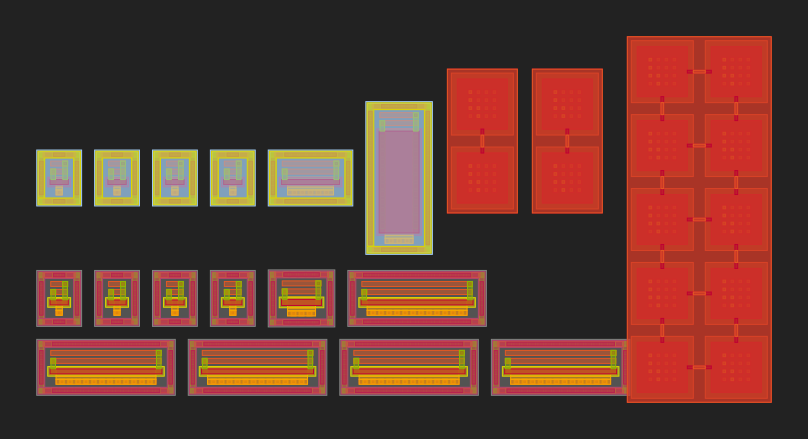

In [749]:
stdp_comp.show()
display_component(stdp_comp, scale = 1,path=".")

In [750]:
# =========================================================================
# 3. ROUTING & NET CONNECTIONS
# =========================================================================
# https://gemini.google.com/app/131a537106def8cd
#but modified with extra vias for routing
# --- A. POWER & GROUND RAILS (avdd & avss) ---

# Connect PMOS sources to avdd rail
stdp_comp << straight_route(pdk, xm1_ref.ports["multiplier_0_source_W"], xm2_ref.ports["multiplier_0_source_E"])
stdp_comp << straight_route(pdk, xm7_ref.ports["multiplier_0_source_W"], xm17_ref.ports["multiplier_0_source_E"])
stdp_comp << straight_route(pdk, xm16_ref.ports["multiplier_0_source_W"], cpot_ref.ports["row1_col0_top_met_S"])
# Connect NMOS sources/bulks to avss rail
stdp_comp << straight_route(pdk, xm4_ref.ports["multiplier_0_source_E"], xm3_ref.ports["multiplier_0_source_W"])
stdp_comp << straight_route(pdk, xm9_ref.ports["multiplier_0_source_E"], xmcm_1_ref.ports["multiplier_0_source_W"])
stdp_comp << straight_route(pdk, chain_refs[3].ports["multiplier_0_source_E"], chain_refs[4].ports["multiplier_0_source_W"])
# Connect MIM Capacitor Ground plates to avss
stdp_comp << straight_route(pdk, cw_ref.ports["row0_col0_bottom_met_W"], chain_refs[4].ports["multiplier_0_source_W"])
stdp_comp << straight_route(pdk, cdep_ref.ports["row0_col0_bottom_met_S"], chain_refs[4].ports["multiplier_0_source_W"])

# --- B. INTERNAL NET ROUTING ---
# net1: XM1 Drain -> XM2 Source
stdp_comp << straight_route(pdk, xm1_ref.ports["multiplier_0_drain_E"], xm2_ref.ports["multiplier_0_source_W"])


# net2: XM3 Source -> XM4 Drain
stdp_comp << straight_route(pdk, xm3_ref.ports["multiplier_0_source_E"], xm4_ref.ports["multiplier_0_drain_W"])

# net3: XM7 Drain -> XMCM_1 Drain
viam2m3 = via_stack(pdk, "met2", "met3", centered=True) #met2 is the bottom layer. met3 is the top layer.
xm7_xmcm_via = stdp_comp << viam2m3
xm7_xmcm_via.move(xm7_ref.ports["multiplier_0_drain_E"].center).movex(8).movey(3)
stdp_comp << L_route(pdk, xm7_ref.ports["multiplier_0_drain_N"], xm7_xmcm_via.ports["bottom_met_W"])
stdp_comp << L_route(pdk, xm7_xmcm_via.ports["top_met_S"], xmcm_1_ref.ports["multiplier_0_drain_W"])

# net4: XM7 Gate -> XM8 Drain
stdp_comp << straight_route(pdk, xm7_ref.ports["multiplier_0_gate_E"], xm8_ref.ports["multiplier_0_drain_W"])


# net5: XM9 Diode connection (Drain to Gate) and connecting to XM12 Drain & XM16 Drain
stdp_comp << straight_route(pdk, xm9_ref.ports["multiplier_0_drain_E"], xm9_ref.ports["multiplier_0_gate_E"])
stdp_comp << straight_route(pdk, xm9_ref.ports["multiplier_0_drain_E"], xm12_ref.ports["multiplier_0_drain_W"])
viam2m3 = via_stack(pdk, "met2", "met3", centered=True) #met2 is the bottom layer. met3 is the top layer.
xm16_xm9_via = stdp_comp << viam2m3
xm16_xm9_via.move(xm9_ref.ports["multiplier_0_drain_W"].center).movex(-2)
stdp_comp << straight_route(pdk, xm9_ref.ports["multiplier_0_drain_W"],xm16_xm9_via.ports["bottom_met_E"])
stdp_comp << L_route(pdk, xm16_xm9_via.ports["top_met_N"], xm16_ref.ports["multiplier_0_drain_W"])




# vpot: XM1 Gate -> XM8 Source -> XM17 Drain -> Cpot Top Plate
stdp_comp << straight_route(pdk, xm1_ref.ports["multiplier_0_gate_E"], xm8_ref.ports["multiplier_0_source_W"])
stdp_comp << straight_route(pdk, xm8_ref.ports["multiplier_0_source_E"], xm17_ref.ports["multiplier_0_drain_W"])
stdp_comp << straight_route(pdk, xm17_ref.ports["multiplier_0_drain_E"], cpot_ref.ports["row0_col0_top_met_W"])



# vdep: XM4 Gate -> XM12 Source -> Cdep Top Plate -> XMCM_5 Drain
stdp_comp << straight_route(pdk, xm4_ref.ports["multiplier_0_gate_E"], xm12_ref.ports["multiplier_0_source_W"])
stdp_comp << L_route(pdk, xm12_ref.ports["multiplier_0_source_E"], cdep_ref.ports["row1_col0_top_met_S"])
stdp_comp << L_route(pdk, cdep_ref.ports["row0_col0_top_met_S"], chain_refs[0].ports["multiplier_0_drain_E"])


# vw (Weight node): XM2 Drain -> XM3 Drain -> Cw Top Plate
viam2m3 = via_stack(pdk, "met2", "met3", centered=True) #met2 is the bottom layer. met3 is the top layer.
cw_via = stdp_comp << viam2m3
cw_via.move(xm2_ref.ports["multiplier_0_drain_W"].center).movex(-2).movey(-7)
stdp_comp << L_route(pdk, xm2_ref.ports["multiplier_0_drain_W"], cw_via.ports["top_met_N"])
stdp_comp << c_route(pdk, cw_via.ports["bottom_met_W"], xm3_ref.ports["multiplier_0_drain_W"])
stdp_comp << c_route(pdk, cw_via.ports["top_met_N"], cw_ref.ports["row4_col0_top_met_N"])

ComponentReference (parent Component "c_route_57c59559", ports ['con_E', 'con_W'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

In [ ]:
# --- C. LONG-CHANNEL BIAS CHAIN SERIES CONNECTIONS (XMCM_5 to XMCM_9) ---
# net6: XMCM_5 Source -> XMCM_6 Drain
viam2m3 = via_stack(pdk, "met2", "met3", centered=True) #met2 is the bottom layer. met3 is the top layer.
drain_1_via = stdp_comp << viam2m3
drain_1_via.move((chain_refs[1].ports["multiplier_0_drain_N"].center[0], 6.3))
stdp_comp << c_route(pdk, chain_refs[0].ports["multiplier_0_source_E"], drain_1_via.ports["bottom_met_E"])
stdp_comp << straight_route(pdk, drain_1_via.ports["top_met_S"], chain_refs[1].ports["multiplier_0_drain_N"])

ComponentReference (parent Component "straight_route_023f1eec", ports ['route_W', 'route_N', 'route_E', 'route_S'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

In [752]:


# net7: XMCM_6 Source -> XMCM_7 Drain
stdp_comp << straight_route(pdk, chain_refs[1].ports["multiplier_0_source_E"], chain_refs[2].ports["multiplier_0_drain_W"])

# net8: XMCM_7 Source -> XMCM_9 Drain
stdp_comp << straight_route(pdk, chain_refs[2].ports["multiplier_0_source_E"], chain_refs[4].ports["multiplier_0_drain_W"])

# net9: XMCM_9 Source -> XMCM_8 Drain
stdp_comp << straight_route(pdk, chain_refs[4].ports["multiplier_0_source_W"], chain_refs[3].ports["multiplier_0_drain_E"])

ComponentReference (parent Component "straight_route_c3bb99a7", ports ['route_W', 'route_N', 'route_E', 'route_S'], origin (0.0, 0.0), rotation 0.0, x_reflection False)

In [753]:

# Connect all Gates of XMCM_5..9 bias chain to vb_itd line
for i in range(len(chain_refs) - 1):
    stdp_comp << straight_route(pdk, chain_refs[i].ports["multiplier_0_gate_E"], chain_refs[i+1].ports["multiplier_0_gate_W"])

2026-08-05 22:51:02.817 | INFO     | gdsfactory.klive:show:55 - Message from klive: {"version": "0.4.1", "klayout_version": "0.30.8", "type": "open", "file": "/tmp/gdsfactory/stdp_lvs$140.gds"}


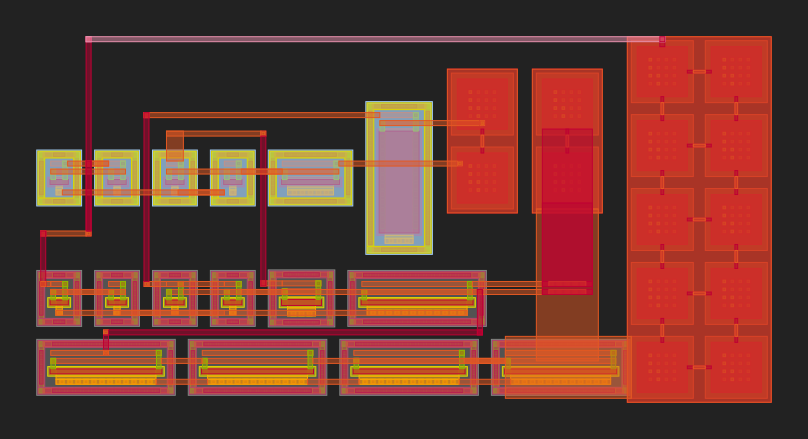

In [754]:
stdp_comp.show()
display_component(stdp_comp, scale = 1,path=".")

In [755]:
stdp_comp.name="stdp_lvs"
drc_result = gf180.drc_magic(stdp_comp, stdp_comp.name)

/headless/conda-env/miniconda3/envs/GLdev/lib/python3.10/site-packages/glayout/pdk/mappedpdk.py:540: UserWarning: Unnamed cells, 19 in 'stdp_lvs$141'
  layout.write_gds(gds_path)
2026-08-05 22:51:03.133 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpbmjzd068/stdp_lvs$141.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl

Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:17:18 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpbmjzd068/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0

In [756]:
# =========================================================================
# 5. ADD MET2 PHYSICAL PINS AND LABELS FOR LVS
# =========================================================================

# Define MET2 pin and label layers for GF180MCU
MET2_PIN_LAYER = (38, 5)  # met2.pin
MET2_LABEL_LAYER = (38, 5)  # met2.label / met2.pin

# Map port names to their source port objects
pins_to_create = {
    "avdd": xm1_ref.ports["multiplier_0_source_W"],
    "avss": xm3_ref.ports["multiplier_0_source_W"],
    "nvpost": xm2_ref.ports["multiplier_0_gate_E"],
    "nvpre": xm8_ref.ports["multiplier_0_gate_E"],
    "vpost": xm12_ref.ports["multiplier_0_gate_E"],
    "vpre": xm3_ref.ports["multiplier_0_gate_E"],
    "vb_idep": xm16_ref.ports["multiplier_0_gate_E"],
    "vb_itd": chain_refs[0].ports["multiplier_0_gate_W"],
    "vb_itp": xm17_ref.ports["multiplier_0_gate_E"],
    "vb_pot": xmcm_1_ref.ports["multiplier_0_gate_E"],
    "vw": cw_ref.ports["row0_col0_top_met_E"],
}

for pin_name, port in pins_to_create.items():
  # Extract center position, size, and orientation from port object
  center = port.center
  width = port.width
  height = port.width  # Standard square pin area around the port center

  # 1. Add pin rectangle shape on met2_pin
  stdp_comp.add_polygon(
      [
          (center[0] - width / 2, center[1] - height / 2),
          (center[0] + width / 2, center[1] - height / 2),
          (center[0] + width / 2, center[1] + height / 2),
          (center[0] - width / 2, center[1] + height / 2),
      ],
      layer=MET2_PIN_LAYER,
  )

  # 2. Add text label on met2_pin layer for net identity
  stdp_comp.add_label(
      text=pin_name, position=center, layer=MET2_LABEL_LAYER, magnification=1.5
  )

# # Save final layout with physical pins & labels
# stdp_comp.write_gds("stdp_lvs_complete.gds")

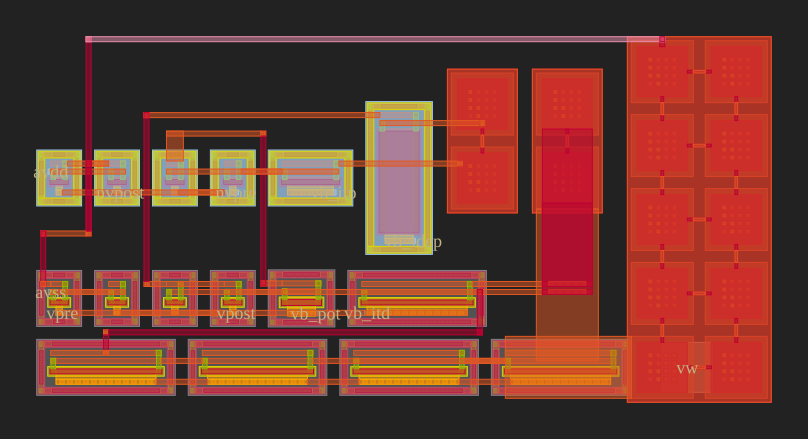

/headless/conda-env/miniconda3/envs/GLdev/lib/python3.10/site-packages/gdsfactory/show.py:40: UserWarning: Unnamed cells, 19 in 'stdp_lvs$141'
  gdspath = component.write_gds(
2026-08-05 22:51:06.097 | INFO     | gdsfactory.klive:show:55 - Message from klive: {"version": "0.4.1", "klayout_version": "0.30.8", "type": "open", "file": "/tmp/gdsfactory/stdp_lvs$141.gds"}


In [757]:
display_component(stdp_comp, scale = 1,path=".")
stdp_comp.show()

In [758]:
stdp_comp.name="stdp_lvs"
drc_result = gf180.drc_magic(stdp_comp, stdp_comp.name)

/headless/conda-env/miniconda3/envs/GLdev/lib/python3.10/site-packages/glayout/pdk/mappedpdk.py:540: UserWarning: Unnamed cells, 19 in 'stdp_lvs$142'
  layout.write_gds(gds_path)
2026-08-05 22:51:06.143 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpazo4qpn9/stdp_lvs$142.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl

Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:17:18 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpazo4qpn9/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0

In [759]:
shift_amount = -prec_center(stdp_comp.flatten())[0];
shift_vertical = -prec_center(stdp_comp.flatten())[1];
tap_ring = tapring(pdk, enclosed_rectangle=evaluate_bbox(stdp_comp.flatten(), padding=pdk.get_grule("nwell")['min_separation']+1));
tring_ref = stdp_comp << tap_ring;
tring_ref.movex(destination=shift_amount).movey(destination=shift_vertical);
# tring_ref.movey(7)
component = component_snap_to_grid(rename_ports_by_orientation(stdp_comp))

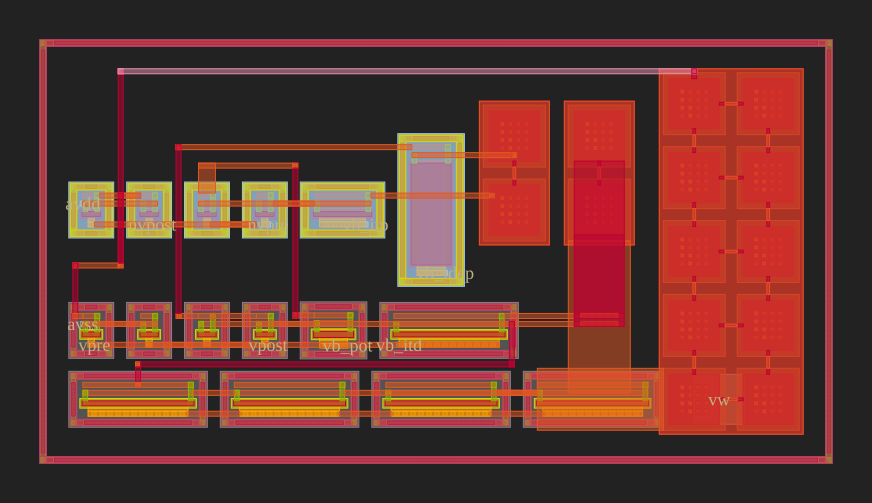

/headless/conda-env/miniconda3/envs/GLdev/lib/python3.10/site-packages/gdsfactory/show.py:40: UserWarning: Unnamed cells, 20 in 'stdp_lvs$142'
  gdspath = component.write_gds(
2026-08-05 22:51:08.404 | INFO     | gdsfactory.klive:show:55 - Message from klive: {"version": "0.4.1", "klayout_version": "0.30.8", "type": "open", "file": "/tmp/gdsfactory/stdp_lvs$142.gds"}


In [760]:
display_component(stdp_comp, scale = 1,path=".")
stdp_comp.show()

In [761]:
stdp_comp.name="stdp_lvs"
drc_result = gf180.drc_magic(stdp_comp, stdp_comp.name)

/headless/conda-env/miniconda3/envs/GLdev/lib/python3.10/site-packages/glayout/pdk/mappedpdk.py:540: UserWarning: Unnamed cells, 20 in 'stdp_lvs$143'
  layout.write_gds(gds_path)
2026-08-05 22:51:08.541 | INFO     | gdsfactory.component:_write_library:1851 - Wrote to '/tmp/tmpf08hg9uk/stdp_lvs$143.gds'


using default pdk_root
Defaulting to stale magic_commands.tcl

Magic 8.3 revision 636 - Compiled on Thu Apr 16 09:17:18 PM CEST 2026.
Starting magic under Tcl interpreter
Using the terminal as the console.
Using NULL graphics device.
Processing system .magicrc file
Switching to WIRING tool.
Switching to NETLIST tool.
Switching to PICK tool.
Switching to BOX tool.
Sourcing design .magicrc for technology gf180mcuD ...
10 Magic internal units = 1 Lambda
Input style import: scaleFactor=10, multiplier=2
The following types are not handled by extraction and will be treated as non-electrical types:
    obsactive mvobsactive filldiff fillpoly m1hole obsm1 fillm1 obsv1 m2hole obsm2 fillm2 obsv2 m3hole obsm3 fillm3 m4hole obsm4 fillm4 m5hole obsm5 fillm5 glass fillblock lvstext obscomment 
Scaled tech values by 10 / 1 to match internal grid scaling
Loading gf180mcuD Device Generator Menu ...
Loading "/tmp/tmpf08hg9uk/magic_commands.tcl" from command line.
Library written using GDS-II Release 6.0

In [762]:
evaluate_bbox(stdp_comp)

(79.32, 42.44)

In [763]:
stdp_est_area = evaluate_bbox(stdp_comp)[0] * evaluate_bbox(stdp_comp)[1]
stdp_est_area

3366.3407999999995

In [764]:
#the spice file of the circuit, from xschem
#  .subckt stdp_lvs avss avdd nvpost nvpre vpost vpre vb_idep vb_itd vb_itp vb_pot vw
# *.PININFO avss:B avdd:B nvpost:B nvpre:B vpost:B vpre:B vb_idep:B vb_itd:B vb_itp:B vb_pot:B vw:B
# XM1 net1 vpot avdd avdd pfet_03v3 L=0.63u W=0.5 nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XM2 vw nvpost net1 avdd pfet_03v3 L=0.63u W=0.5 nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XM3 vw vpre net2 avss nfet_03v3 L=0.63u W=0.5 nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XM4 net2 vdep avss avss nfet_03v3 L=0.63u W=0.5 nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XM7 net3 net4 avdd avdd pfet_03v3 L=0.63u W=0.5 nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XCpot avdd vpot cap_mim_2f0fF c_width=5e-6 c_length=5e-6 m=2
# XM8 net4 nvpre vpot avdd pfet_03v3 L=0.63u W=0.5 nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XCW vw avss cap_mim_2f0fF c_width=5e-6 c_length=5e-6 m=10
# XM9 net5 net5 avss avss nfet_03v3 L=0.63u W=0.5 nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XM12 net5 vpost vdep avss nfet_03v3 L=0.63u W=0.5 nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XCdep vdep avss cap_mim_2f0fF c_width=5e-6 c_length=5e-6 m=2
# XM17 vpot vb_itp avdd avdd pfet_03v3 L=4.6u W=0.3u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XMCM_1 net3 vb_pot avss avss nfet_03v3 L=2.8u W=0.61u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XM16 net5 vb_idep avdd avdd pfet_03v3 L=2.8u W=10.2u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XMCM_5 vdep vb_itd net6 avss nfet_03v3 L=10u W=0.5u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XMCM_6 net6 vb_itd net7 avss nfet_03v3 L=10u W=0.5u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XMCM_7 net7 vb_itd net8 avss nfet_03v3 L=10u W=0.5u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XMCM_8 net9 vb_itd avss avss nfet_03v3 L=10u W=0.5u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# XMCM_9 net8 vb_itd net9 avss nfet_03v3 L=10u W=0.5u nf=1 ad='int((nf+1)/2) * W/nf * 0.18u' as='int((nf+2)/2) * W/nf * 0.18u' pd='2*int((nf+1)/2) * (W/nf + 0.18u)'
# + ps='2*int((nf+2)/2) * (W/nf + 0.18u)' nrd='0.18u / W' nrs='0.18u / W' sa=0 sb=0 sd=0
# .ends 
